In [3]:
import torch
import torch.nn as nn
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence # http://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html
from tqdm import tqdm

In [4]:
def collate_fn_transformer(batch):
    """
    Custom function that defines how batches are formed.

    To process the batch items that each have a different number of hits, it is efficient
    to first concatenate all the data into a single tensor and save the lengths of each
    individual event to be able to split the data again later.

    # F: input_dim, number of features (time, x, y)
    # N: number of hits (different for each event)
    # B: batch size

    The resulting 2D tensor has the shape (B x N, F) where B is the batch size, N is the total number of hits of all events
    in the batch, and F is the number of features (time, x, y).


    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each graph.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.
    Returns
    -------
    packed_data : Batch
        A batch of graph data objects.
    labels : torch.Tensor
        A tensor containing the labels for each graph.
    """
    data_list = []
    labels = []
    lengths=[]

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the feautures are (time, x, y)
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensordata = tensordata.to(dtype=torch.float32)

        lengths.append(tensordata.shape[0])

        data_list.append(tensordata)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) # convert the list of tensors to a single tensor

    data_vec=torch.cat(data_list) # (B, N, F)  -> (BxN, F) where B is the batch size, N is the number of hits, and F is the number of features (time, x, y)

    ## return a list [datalist, lengths]
    return [data_vec, lengths], labels

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim=3,
        hidden_dim=256,
        output_dim=2,
        num_heads=8,
        num_layers=3,
        dim_feedforward=512
    ):
        super().__init__()

        # define the input embedding layer
        self.input_embedding = nn.Linear(input_dim, hidden_dim)

        # one encoding layer
        encoder_layer = nn.TransformerEncoderLayer(  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html
            d_model=hidden_dim, # number of expected features in the input
            nhead=num_heads, # H (number of heads)
            dim_feedforward=dim_feedforward, # dimension of MLP
            activation="relu",
            batch_first=True,
            norm_first=True,
            dropout=0.02
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html

        # define the output projection layer
        self.output_projection = nn.Linear(hidden_dim, output_dim)

    def forward(self, data) -> torch.Tensor:
        """
        Args:
            data: list of (src tensor, lengths)
        Returns:
            Tensor of shape (batch, output_dim)
        """

        src, lengths = data

        # F: input_dim, number of features (time, x, y)
        # N: number of hits
        # D: hidden_dim, internal transformer computing dimension
        # B: batch size

        # 1) embed the input data into the hidden dimension
          # shape (B x N, F) -> (B x N, D)
        src = self.input_embedding(src) 

        # 2) split the data into a list of tensors, one for each event
        parts = src.split(lengths, dim=0)  # shape (B x N, D) -> (B, N, D), where every batch entry can have a variable length,
                                           # i.e., list of tensors of shape (N_i, D) where N_i is the number of hits in the i-th event


        # 3) pad inputs with zeros so that all batch items have same length
        padded = pad_sequence(parts, batch_first=True) # shape (B, N, D) -> (B x MAXLEN x D) now all batch entries have the same length
        batch_size, max_len, _ = padded.shape

        # 4) build the padding mask (batch_size, max_len)
        # we need to keep track which tokens are padding tokens and which are real tokens
        # the mask is a boolean tensor of shape (B, MAXLEN) where True indicates that the corresponding entry is a padding token
        # and False indicates that the corresponding entry is a real token
        # the mask is used to ignore the padding tokens in the attention mechanism
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool).to(device=padded.device, dtype=torch.bool)
        for i, L in enumerate(lengths):
            mask[i, L:] = True

        # 5) call the transformer with padded tensor of shape (B, MAXLEN, D) and corresponding mask of shape (B, MAXLEN)
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        # 6) masked mean‐pool, i.e., form the average for every batch item along the sequence dimension
        # the output of the transformer is a tensor of shape (B, MAXLEN, D)
        # we need to take the mean over the sequence dimension (MAXLEN) to get a single vector for each batch item
        # we need to ignore the padding tokens in the mean pooling
        # the resulting shape is (B, D)
        valid_mask = ~mask
        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)
        pooled = summed / torch.LongTensor(lengths)[:,None].to(enc_out)

        # 7) apply a final linear layer to get the output of shape (B, output_dim)
        out = self.output_projection(pooled)
        return out

In [6]:
# import data

train_data = ak.from_parquet("../data/train.pq")
val_data = ak.from_parquet("../data/val.pq")
test_data = ak.from_parquet("../data/test.pq")

In [ ]:
# Data loaders

batch_size = 256

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_transformer,
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_transformer,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_transformer,
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = TransformerEncoder().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Device: cpu


/tmp/ipykernel_107013/480566360.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html


In [9]:
def move_batch_to_device(batch, device):
    data, labels = batch
    src, lengths = data

    src = src.to(device)
    labels = labels.to(device)

    return [src, lengths], labels

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0

    for batch in loader:
        data, labels = move_batch_to_device(batch, device)

        optimizer.zero_grad()

        predictions = model(data)
        loss = loss_fn(predictions, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.shape[0]

    return total_loss / len(loader.dataset)


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            data, labels = move_batch_to_device(batch, device)

            predictions = model(data)
            loss = loss_fn(predictions, labels)

            total_loss += loss.item() * labels.shape[0]

    return total_loss / len(loader.dataset)

In [ ]:
# train model

num_epochs = 50

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss = evaluate(model, val_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}: train loss = {train_loss:.5f}, val loss = {val_loss:.5f}")

Epoch 01: train loss = 10.89121, val loss = 5.14072
Epoch 02: train loss = 4.36744, val loss = 3.93516
Epoch 03: train loss = 3.64061, val loss = 3.54729
Epoch 04: train loss = 3.24249, val loss = 3.41051
Epoch 05: train loss = 3.00067, val loss = 2.94708
Epoch 06: train loss = 2.83162, val loss = 2.75633
Epoch 07: train loss = 2.75736, val loss = 2.89546
Epoch 08: train loss = 2.64956, val loss = 2.90414
Epoch 09: train loss = 2.45709, val loss = 2.59236
Epoch 10: train loss = 2.55243, val loss = 2.80892
Epoch 11: train loss = 2.48418, val loss = 2.68012
Epoch 12: train loss = 2.35700, val loss = 2.56271
Epoch 13: train loss = 2.32466, val loss = 2.59814
Epoch 14: train loss = 2.34231, val loss = 2.46422
Epoch 15: train loss = 2.28325, val loss = 2.40966
Epoch 16: train loss = 2.28426, val loss = 2.55576
Epoch 17: train loss = 2.17569, val loss = 2.54974
Epoch 18: train loss = 2.20891, val loss = 2.60958
Epoch 19: train loss = 2.20029, val loss = 2.22490
Epoch 20: train loss = 2.11077

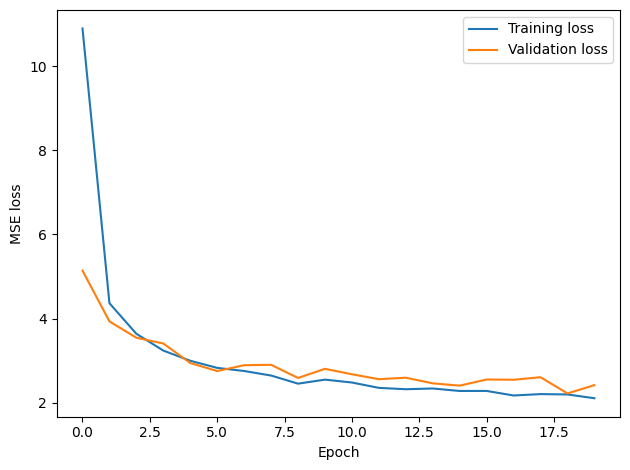

In [11]:
# loss curve

plt.figure()
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.savefig("A8_loss_curve.png", dpi=300)
plt.show()

In [12]:
model.eval()

predictions = []
truths = []

with torch.no_grad():
    for batch in test_loader:
        data, labels = move_batch_to_device(batch, device)

        pred = model(data)

        predictions.append(pred.cpu().numpy())
        truths.append(labels.cpu().numpy())

predictions = np.concatenate(predictions, axis=0)
truths = np.concatenate(truths, axis=0)

In [13]:
# Error

residuals = predictions - truths

mae = np.mean(np.abs(residuals), axis=0)
rmse = np.sqrt(np.mean(residuals ** 2, axis=0))

distance_error = np.sqrt(np.sum(residuals ** 2, axis=1))

print(f"MAE x: {mae[0]:.3f} m")
print(f"MAE y: {mae[1]:.3f} m")
print(f"RMSE x: {rmse[0]:.3f} m")
print(f"RMSE y: {rmse[1]:.3f} m")
print(f"Mean 2D error: {distance_error.mean():.3f} m")
print(f"Median 2D error: {np.median(distance_error):.3f} m")

MAE x: 0.868 m
MAE y: 1.172 m
RMSE x: 1.328 m
RMSE y: 1.733 m
Mean 2D error: 1.615 m
Median 2D error: 1.127 m


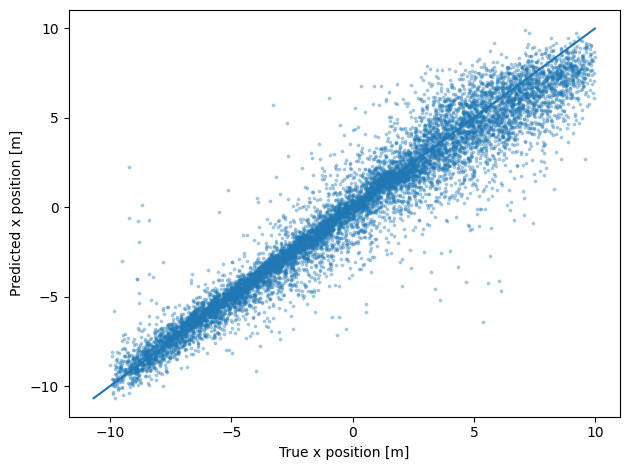

In [14]:
# true vs predicted x

plt.figure()
plt.scatter(truths[:, 0], predictions[:, 0], s=3, alpha=0.3)

min_val = min(truths[:, 0].min(), predictions[:, 0].min())
max_val = max(truths[:, 0].max(), predictions[:, 0].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True x position [m]")
plt.ylabel("Predicted x position [m]")
plt.tight_layout()
plt.savefig("A8_pred_vs_true_x.png", dpi=300)
plt.show()

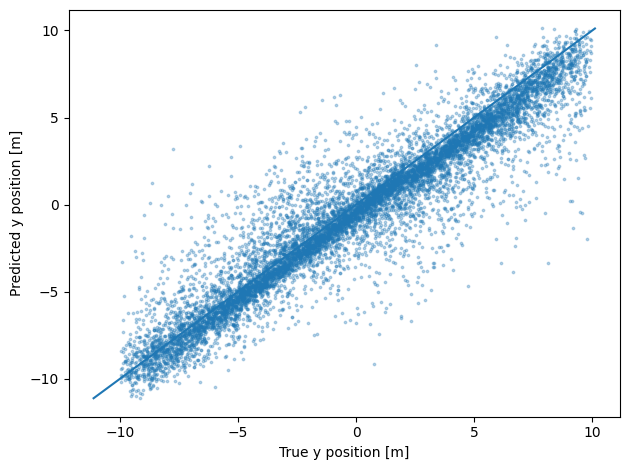

In [15]:
# true vs predicted y

plt.figure()
plt.scatter(truths[:, 1], predictions[:, 1], s=3, alpha=0.3)

min_val = min(truths[:, 1].min(), predictions[:, 1].min())
max_val = max(truths[:, 1].max(), predictions[:, 1].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True y position [m]")
plt.ylabel("Predicted y position [m]")
plt.tight_layout()
plt.savefig("A8_pred_vs_true_y.png", dpi=300)
plt.show()

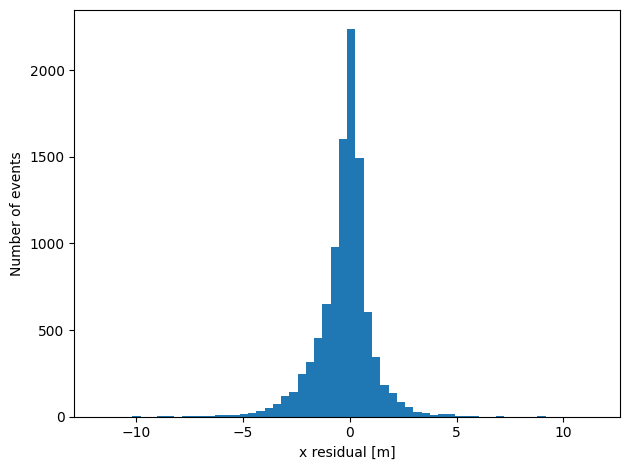

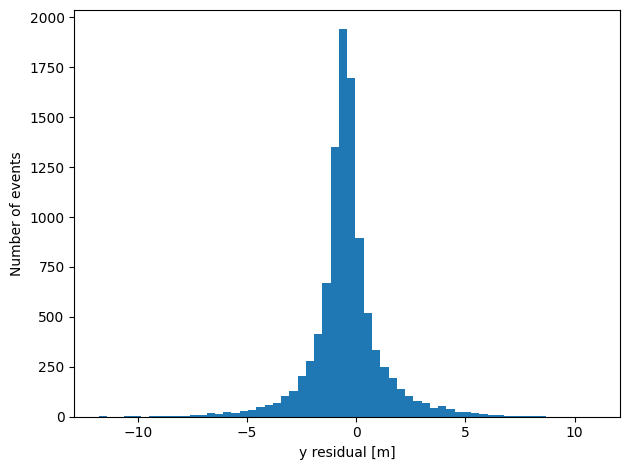

In [16]:
# residuals

plt.figure()
plt.hist(residuals[:, 0], bins=60)
plt.xlabel("x residual [m]")
plt.ylabel("Number of events")
plt.tight_layout()
plt.savefig("A8_residual_x.png", dpi=300)
plt.show()

plt.figure()
plt.hist(residuals[:, 1], bins=60)
plt.xlabel("y residual [m]")
plt.ylabel("Number of events")
plt.tight_layout()
plt.savefig("A8_residual_y.png", dpi=300)
plt.show()

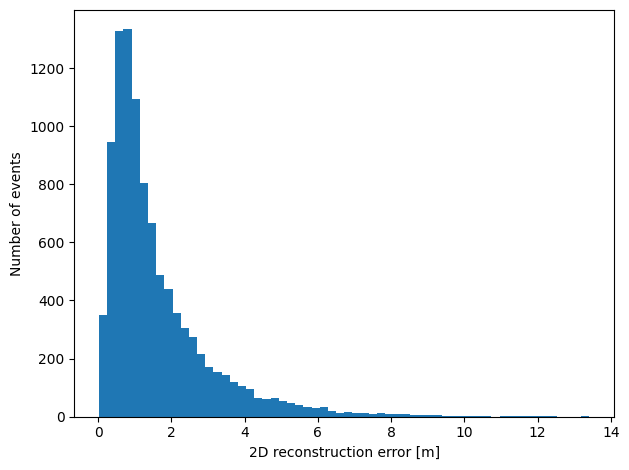

In [17]:
# 2d distance error

plt.figure()
plt.hist(distance_error, bins=60)
plt.xlabel("2D reconstruction error [m]")
plt.ylabel("Number of events")
plt.tight_layout()
plt.savefig("A8_2d_error.png", dpi=300)
plt.show()